<a href="https://colab.research.google.com/github/saiKelkar/Product_Oriented_Scan-to-CAD_Dimensional_Inspection_System/blob/main/scan_to_cad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install open3d

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import Open3D and NumPy
import open3d as o3d
import numpy as np

In [4]:
CAD_PATH = "/content/drive/MyDrive/Scan-to-CAD_System/Lbracket.stl"
print(CAD_PATH)

/content/drive/MyDrive/Scan-to-CAD_System/Lbracket.stl


In [5]:
# Load the L-bracket (nominal STL)
mesh = o3d.io.read_triangle_mesh(CAD_PATH)

print(mesh)

TriangleMesh with 2128 points and 1140 triangles.


In [6]:
# Inspect Mesh
print("Vertices:", len(mesh.vertices))
print("Triangles:", len(mesh.triangles))
print("Is empty:", mesh.is_empty())

Vertices: 2128
Triangles: 1140
Is empty: False


In [7]:
# Find the mesh dimensions (bounding box)
bbox = mesh.get_axis_aligned_bounding_box()

min_bound = bbox.get_min_bound()
max_bound = bbox.get_max_bound()
dimensions = bbox.get_extent()

print("Minimum coordinates:", min_bound)
print("Maximum coordinates:", max_bound)

print("\nBounding-box dimensions:")
print("X:", dimensions[0])
print("Y:", dimensions[1])
print("Z:", dimensions[2])

Minimum coordinates: [-1. -1.  0.]
Maximum coordinates: [14.  48.5 49.5]

Bounding-box dimensions:
X: 15.0
Y: 49.5
Z: 49.5


In [8]:
# Visualize nominal CAD
import plotly.graph_objects as go

vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)

fig = go.Figure(
    data=[
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=triangles[:, 0],
            j=triangles[:, 1],
            k=triangles[:, 2],
            opacity=0.8
        )
    ]
)

fig.update_layout(
    title="Nominal CAD - L-Bracket",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=800,
    height=650
)

fig.show()

### Nominal CAD Coordinate System
- X: bracket width
- Y: horizontal flange direction
- Z: vertical flange direction

Overall bounding dimensions:
- X: 15.0 mm
- Y: 49.5 mm
- Z: 49.5 mm

In [9]:
vertices = np.asarray(mesh.vertices)

print("Shape:", vertices.shape)
print("\nFirst 10 vertices:")
print(vertices[:10])

Shape: (2128, 3)

First 10 vertices:
[[14.          3.5         0.77273029]
 [14.         47.72726822  0.77273029]
 [14.         47.72726822  3.72726965]
 [14.          2.72726965  3.72726965]
 [ 5.22037363 37.57077026  0.        ]
 [ 4.85345554 37.37464905  0.        ]
 [-0.46701497 47.48698425  0.        ]
 [13.44318295 47.48727036  0.        ]
 [ 7.93122196 37.46218872  0.        ]
 [ 7.72808933 37.57077026  0.        ]]


In [10]:
# Computing normals
mesh.compute_vertex_normals()

print(mesh)

TriangleMesh with 2128 points and 1140 triangles.


In [11]:
pcd_perfect = mesh.sample_points_poisson_disk(
    number_of_points=10000
)

print(pcd_perfect)

PointCloud with 10000 points.


In [12]:
points = np.asarray(pcd_perfect.points)

print("Shape:", points.shape)
print("\nFirst 10 points:")
print(points[:10])

Shape: (10000, 3)

First 10 points:
[[ 6.28158732  3.5        27.88655398]
 [ 7.72130228 25.76831465  4.5       ]
 [12.05351577 -1.          7.01089761]
 [ 9.96664475 11.60055456  0.        ]
 [-0.89697861  2.87718366  4.62897221]
 [ 4.27326405 -0.05660645 21.13930624]
 [-0.08483002  8.55950595  4.5       ]
 [ 5.63044672 -1.         44.65046418]
 [13.60945622  5.11204911  0.3821863 ]
 [ 6.17309931 18.637897    4.41146321]]


In [13]:
points = np.asarray(pcd_perfect.points)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(
                size=2
            )
        )
    ]
)

fig.update_layout(
    title="Perfect Synthetic Scan - 10,000 Points",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=800,
    height=650
)

fig.show()

In [14]:
# Saving the .ply file
OUTPUT_PATH = "/content/drive/MyDrive/Scan-to-CAD_System/perfect_scan.ply"

o3d.io.write_point_cloud(
    OUTPUT_PATH,
    pcd_perfect
)

print("Saved to:", OUTPUT_PATH)

Saved to: /content/drive/MyDrive/Scan-to-CAD_System/perfect_scan.ply


In [15]:
# Calculating bounding box of our point cloud
pcd_bbox = pcd_perfect.get_axis_aligned_bounding_box()

print("CAD dimensions:", mesh.get_axis_aligned_bounding_box().get_extent())
print("\nPoint cloud dimensions:", pcd_bbox.get_extent())

CAD dimensions: [15.  49.5 49.5]

Point cloud dimensions: [15.  49.5 49.5]


In [16]:
vertices = np.asarray(mesh.vertices)

x = vertices[:, 0]
y = vertices[:, 1]
z = vertices[:, 2]

print("X range:", x.min(), "to", x.max())
print("Y range:", y.min(), "to", y.max())
print("Z range:", z.min(), "to", z.max())

X range: -1.0 to 14.0
Y range: -1.0 to 48.5
Z range: 0.0 to 49.5


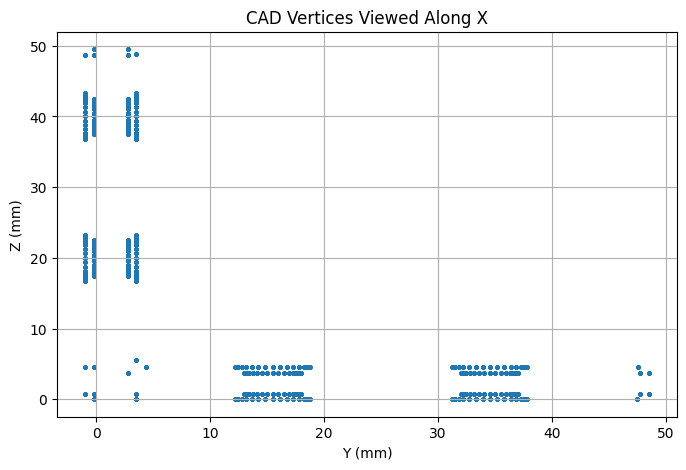

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y, z, s=5)

plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("CAD Vertices Viewed Along X")
plt.grid(True)

plt.show()

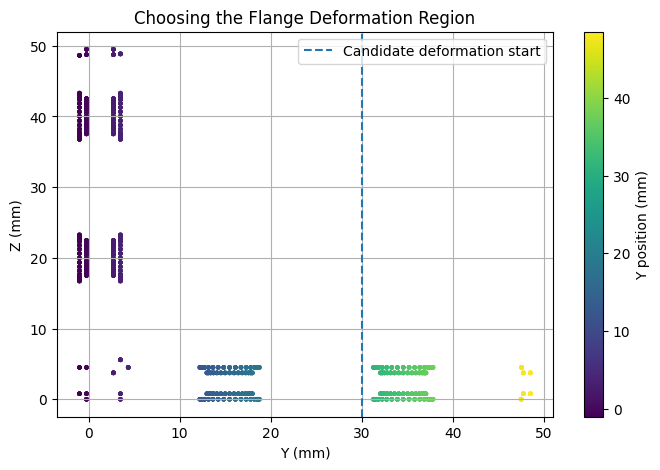

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y,
    z,
    s=5,
    c=y,
    cmap="viridis"
)

plt.axvline(
    x=30,
    linestyle="--",
    label="Candidate deformation start"
)

plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("Choosing the Flange Deformation Region")
plt.colorbar(label="Y position (mm)")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Copy the mesh
import copy

nominal_mesh = copy.deepcopy(mesh)
defective_mesh = copy.deepcopy(mesh)

print("Nominal:", nominal_mesh)
print("Defective:", defective_mesh)

Nominal: TriangleMesh with 2128 points and 1140 triangles.
Defective: TriangleMesh with 2128 points and 1140 triangles.


In [20]:
# Get the defective mesh's vertices
vertices = np.asarray(defective_mesh.vertices).copy()

print(vertices.shape)
print(vertices[: 5])

(2128, 3)
[[14.          3.5         0.77273029]
 [14.         47.72726822  0.77273029]
 [14.         47.72726822  3.72726965]
 [14.          2.72726965  3.72726965]
 [ 5.22037363 37.57077026  0.        ]]


In [21]:
x = vertices[:, 0]
y = vertices[:, 1]
z = vertices[:, 2]

In [22]:
deformation_mask = (y > 30.0) & (z < 6.0)

print("Total vertices:", len(vertices))
print("Vertices selected for deformation:", np.sum(deformation_mask))

Total vertices: 2128
Vertices selected for deformation: 540


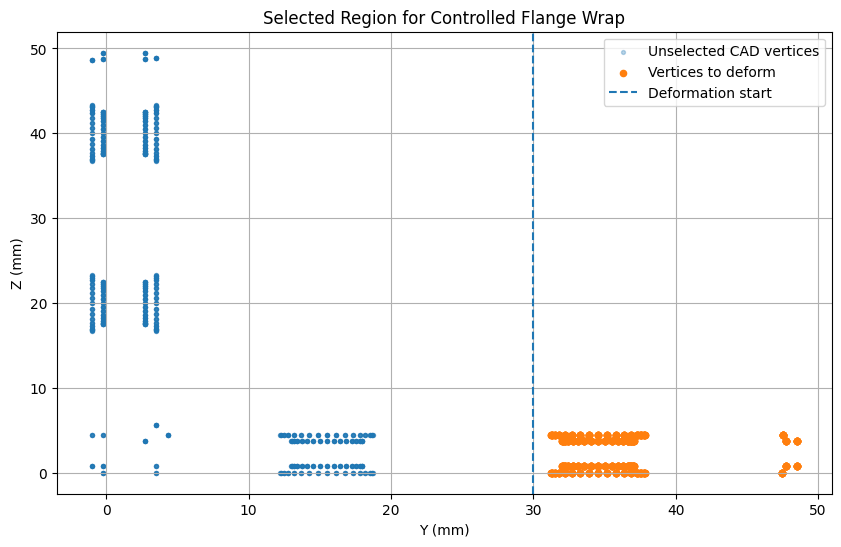

In [23]:
plt.figure(figsize=(10, 6))

# All vertices
plt.scatter(
    y,
    z,
    s=8,
    alpha=0.3,
    label="Unselected CAD vertices"
)

# Selected vertices
plt.scatter(
    y[deformation_mask],
    z[deformation_mask],
    s=20,
    label="Vertices to deform"
)

plt.axvline(30, linestyle="--", label="Deformation start")

plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("Selected Region for Controlled Flange Wrap")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
DEFORMATION_START_Y = 30.0
MAX_Y = nominal_mesh.get_axis_aligned_bounding_box().get_max_bound()[1]
MAX_WARP = 3.0

print("Start Y:", DEFORMATION_START_Y)
print("End Y:", MAX_Y)
print("Maximum warp:", MAX_WARP, "mm")

Start Y: 30.0
End Y: 48.5
Maximum warp: 3.0 mm


In [25]:
t = (y[deformation_mask] - DEFORMATION_START_Y) / (MAX_Y - DEFORMATION_START_Y)

print("Minimum t:", t.min())
print("Maximum t:", t.max())

Minimum t: 0.06849948779956715
Maximum t: 1.0


In [26]:
z_displacement = MAX_WARP * t

print("Minimum displacement:", z_displacement.min(), "mm")
print("Maximim displacement:", z_displacement.max(), "mm")

Minimum displacement: 0.20549846339870143 mm
Maximim displacement: 3.0 mm


In [27]:
vertices[deformation_mask, 2] += z_displacement

defective_mesh.vertices = o3d.utility.Vector3dVector(vertices)
defective_mesh.compute_vertex_normals()

TriangleMesh with 2128 points and 1140 triangles.

In [28]:
nominal_vertices = np.asarray(nominal_mesh.vertices)
defective_vertices = np.asarray(defective_mesh.vertices)

vertex_displacements = np.linalg.norm(
    defective_vertices - nominal_vertices,
    axis=1
)

print("Maximum introduced displacement:", vertex_displacements.max(), "mm")
print("Mean displacement over entire mesh:", vertex_displacements.mean(), "mm")
print("Number of moved vertices:", np.sum(vertex_displacements > 0))

Maximum introduced displacement: 3.0 mm
Mean displacement over entire mesh: 0.2500793270598677 mm
Number of moved vertices: 540


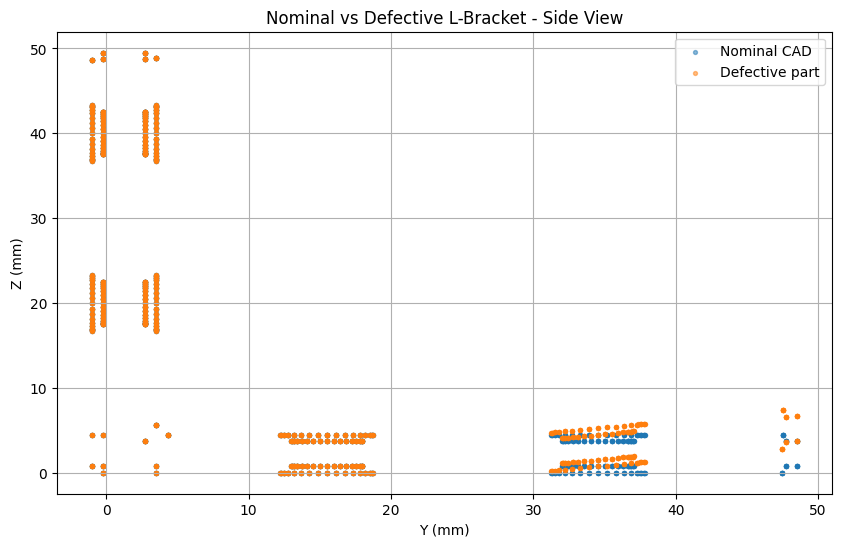

In [29]:
nominal_v = np.asarray(nominal_mesh.vertices)
defective_v = np.asarray(defective_mesh.vertices)

plt.figure(figsize=(10, 6))

plt.scatter(
    nominal_v[:, 1],
    nominal_v[:, 2],
    s=8,
    alpha=0.5,
    label="Nominal CAD"
)

plt.scatter(
    defective_v[:, 1],
    defective_v[:, 2],
    s=8,
    alpha=0.5,
    label="Defective part"
)

plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("Nominal vs Defective L-Bracket - Side View")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
triangles = np.asarray(nominal_mesh.triangles)

fig = go.Figure()

# Nominal CAD
fig.add_trace(
    go.Mesh3d(
        x=nominal_v[:, 0],
        y=nominal_v[:, 1],
        z=nominal_v[:, 2],
        i=triangles[:, 0],
        j=triangles[:, 1],
        k=triangles[:, 2],
        opacity=0.35,
        name="Nominal CAD"
    )
)

# Defective part
fig.add_trace(
    go.Mesh3d(
        x=defective_v[:, 0],
        y=defective_v[:, 1],
        z=defective_v[:, 2],
        i=triangles[:, 0],
        j=triangles[:, 1],
        k=triangles[:, 2],
        opacity=0.65,
        name="Defective Part"
    )
)

fig.update_layout(
    title="Controlled Manufacturing Defect - 6mm Flange Wrap",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=850,
    height=650
)

fig.show()

In [31]:
# Visualize the actual ground-truth displacement
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=defective_v[:, 0],
            y=defective_v[:, 1],
            z=defective_v[:, 2],
            mode="markers",
            marker=dict(
                size=3,
                color=vertex_displacements,
                colorscale="Turbo",
                colorbar=dict(
                    title="Introduced<br>Displacement (mm)"
                )
            )
        )
    ]
)

fig.update_layout(
    title="Ground-Truth Manufacturing Deformation",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=850,
    height=650
)

fig.show()

In [32]:
# Save the defective mesh
DEFECTIVE_PATH = "/content/drive/MyDrive/Scan-to-CAD_System/defective_bracket.stl"

o3d.io.write_triangle_mesh(
    DEFECTIVE_PATH,
    defective_mesh
)

print("Saved defective mesh to:", DEFECTIVE_PATH)

Saved defective mesh to: /content/drive/MyDrive/Scan-to-CAD_System/defective_bracket.stl


In [33]:
# Creating a perfect scan of the defective part
perfect_defective_scan = defective_mesh.sample_points_poisson_disk(
    number_of_points=10000
)

print(perfect_defective_scan)

PointCloud with 10000 points.


In [34]:
scan_points = np.asarray(
    perfect_defective_scan.points
).copy()

print(scan_points.shape)
print(scan_points[:5])

(10000, 3)
[[ 0.9918879  44.08844179  6.78461218]
 [14.          0.72633187 45.52417233]
 [10.67320145  3.5        31.50326404]
 [ 4.61448277 -0.67196829 22.24673451]
 [ 4.19566158 -1.         25.7468848 ]]


In [35]:
NOISE_STD = 0.10

noise = np.random.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=scan_points.shape
)

noisy_points = scan_points + noise

In [36]:
print("Noise shape:", noise.shape)
print("Mean noise:", noise.mean())
print("Noise standard deviation:", noise.std())

Noise shape: (10000, 3)
Mean noise: 0.00019748879390210555
Noise standard deviation: 0.10009718934540929


In [37]:
noisy_scan = o3d.geometry.PointCloud()

noisy_scan.points = o3d.utility.Vector3dVector(noisy_points)

In [38]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=noisy_points[:, 0],
            y=noisy_points[:, 1],
            z=noisy_points[:, 2],
            mode="markers",
            marker=dict(size=2)
        )
    ]
)

fig.update_layout(
    title="Synthetic Scanner Output - Gaussian Noise σ = 0.10 mm",
    scene=dict(
        xaxis_title="X (mm)",
        yaxis_title="Y (mm)",
        zaxis_title="Z (mm)",
        aspectmode="data"
    ),
    width=850,
    height=650
)

fig.show()

In [39]:
n_show = 500

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=scan_points[:n_show, 0],
        y=scan_points[:n_show, 1],
        z=scan_points[:n_show, 2],
        mode="markers",
        marker=dict(size=3),
        name="True surface samples"
    )
)

fig.add_trace(
    go.Scatter3d(
        x=noisy_points[:n_show, 0],
        y=noisy_points[:n_show, 1],
        z=noisy_points[:n_show, 2],
        mode="markers",
        marker=dict(size=3),
        name="Scanner measurements"
    )
)

fig.update_layout(
    title="True Surface Samples vs Noisy Scanner Measurements",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=850,
    height=650
)

fig.show()

In [40]:
DROPOUT_RATE = 0.10

num_points = len(noisy_points)

keep_mask = (np.random.rand(num_points) > DROPOUT_RATE)
scan_with_dropout = noisy_points[keep_mask]

print("Original points:", num_points)
print("After dropout:", len(scan_with_dropout))
print("Points removed:", num_points - len(scan_with_dropout))

Original points: 10000
After dropout: 8998
Points removed: 1002


In [41]:
NUM_OUTLIERS = 150

bbox = defective_mesh.get_axis_aligned_bounding_box()

min_bound = bbox.get_min_bound()
max_bound = bbox.get_max_bound()

margin = 5.0

outliers = np.random.uniform(
    low=min_bound - margin,
    high=max_bound + margin,
    size=(NUM_OUTLIERS, 3)
)

final_scan_points = np.vstack([
    scan_with_dropout,
    outliers
])

print("Real surface observations:", len(scan_with_dropout))
print("Artificial outliers:", NUM_OUTLIERS)
print("Final scan size:", len(final_scan_points))

Real surface observations: 8998
Artificial outliers: 150
Final scan size: 9148


In [42]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=final_scan_points[:, 0],
            y=final_scan_points[:, 1],
            z=final_scan_points[:, 2],
            mode="markers",
            marker=dict(size=2)
        )
    ]
)

fig.update_layout(
    title="Synthetic As-Built Scan — Noise + Dropout + Outliers",
    scene=dict(
        xaxis_title="X (mm)",
        yaxis_title="Y (mm)",
        zaxis_title="Z (mm)",
        aspectmode="data"
    ),
    width=850,
    height=650
)

fig.show()

In [43]:
as_built_scan = o3d.geometry.PointCloud()

as_built_scan.points = o3d.utility.Vector3dVector(
    final_scan_points
)

In [46]:
AS_BUILT_PATH = "/content/drive/MyDrive/Scan-to-CAD_System/as_built_scan.ply"

o3d.io.write_point_cloud(
    AS_BUILT_PATH,
    as_built_scan
)

print("Saved:", AS_BUILT_PATH)

Saved: /content/drive/MyDrive/Scan-to-CAD_System/as_built_scan.ply


In [47]:
scan_original_pose = copy.deepcopy(as_built_scan)
scan_misaligned = copy.deepcopy(as_built_scan)

In [48]:
angle_deg = 25.0
angle_rad = np.deg2rad(angle_deg)

R = np.array([
    [np.cos(angle_rad), -np.sin(angle_rad), 0],
    [np.sin(angle_rad),  np.cos(angle_rad), 0],
    [0,                  0,                 1]
])

print(R)

[[ 0.90630779 -0.42261826  0.        ]
 [ 0.42261826  0.90630779  0.        ]
 [ 0.          0.          1.        ]]


In [49]:
translation = np.array([
    20.0,
    35.0,
    15.0
])

print(translation)

[20. 35. 15.]


In [50]:
T = np.eye(4)

T[:3, :3] = R
T[:3, 3] = translation

print(T)

[[ 0.90630779 -0.42261826  0.         20.        ]
 [ 0.42261826  0.90630779  0.         35.        ]
 [ 0.          0.          1.         15.        ]
 [ 0.          0.          0.          1.        ]]


In [51]:
scan_misaligned.transform(T)

PointCloud with 9148 points.

In [52]:
cad_points = np.asarray(
    nominal_mesh.sample_points_poisson_disk(
        number_of_points=5000
    ).points
)

misaligned_points = np.asarray(
    scan_misaligned.points
)

In [53]:
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=cad_points[:, 0],
        y=cad_points[:, 1],
        z=cad_points[:, 2],
        mode="markers",
        marker=dict(size=2),
        name="Nominal CAD"
    )
)

fig.add_trace(
    go.Scatter3d(
        x=misaligned_points[:, 0],
        y=misaligned_points[:, 1],
        z=misaligned_points[:, 2],
        mode="markers",
        marker=dict(size=2),
        name="Raw Scanner Data"
    )
)

fig.update_layout(
    title="Registration Problem — CAD vs Raw Scan",
    scene=dict(
        xaxis_title="X (mm)",
        yaxis_title="Y (mm)",
        zaxis_title="Z (mm)",
        aspectmode="data"
    ),
    width=900,
    height=700
)

fig.show()